# Calibración del Proxy de Calima v4

**Objetivo:** Usar CAP (alertas oficiales AEMET) y DAI (Dust Aerosol Index, Heliyon) como ground truth para calibrar un proxy regional de calima mediante regresión logística.

**Input:** `data/processed/regional/calibration_dataset_2004_2025.parquet`  
**Output:** coeficientes del proxy + umbrales para niveles ordinales (no_calima / possible / probable / intense)

**Ventana de calibración recomendada:** 2009–2022 (DAI fiable + cobertura PM10 suficiente)

---

## Estructura del notebook
1. Carga y diagnóstico del dataset
2. Análisis del ground truth (DAI + CAP)
3. EDA de calibración — distribuciones por label
4. Regresión logística — calibración del proxy
5. Evaluación (AUC, curva ROC)
6. Umbrales ordinales
7. Exportar coeficientes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.pipeline import Pipeline
import json

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = Path('../data/processed/regional')
OUT_DIR  = DATA_DIR  # coeficientes se guardan aquí

## 1. Carga y diagnóstico

In [3]:
df = pd.read_parquet(DATA_DIR / 'calibration_dataset_2004_2025.parquet')
df['week_start'] = pd.to_datetime(df['week_start'])

print(f"Shape: {df.shape}")
print(f"Rango: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print()
print(df.dtypes)
print()
print("Nulls:")
print(df.isnull().sum())

Shape: (1149, 18)
Rango: 2003-12-29 → 2025-12-29

week_start                    datetime64[ns]
tmin_c_mean                          float64
wind_ms_mean                         float64
low_vis_any_week                     float64
humidity_mean                        float64
PM10                                 float64
temp_c_mean                          float64
vis_min_m_week                       float64
tmax_c_mean                          float64
pressure_hpa_mean                    float64
PM2.5                                float64
calima_canarias_dai_week             float64
calima_canarias_level_week           float64
dai_event                            float64
cap_dust_max_regional                float64
cap_dust_event                       float64
calima_label                           int64
proxy_reliable                         int64
dtype: object

Nulls:
week_start                      0
tmin_c_mean                     0
wind_ms_mean                    0
low_vis_any_week

## 2. Análisis del ground truth (DAI + CAP)

In [5]:
# Inspeccionar rango real del DAI
dai_available = df[df['dai_event'].notna()]
print(f"DAI disponible: {len(dai_available)} semanas")
print(f"  Rango: {dai_available['week_start'].min().date()} → {dai_available['week_start'].max().date()}")
print(f"  Eventos DAI=1: {int(dai_available['dai_event'].sum())}")
print()

cap_available = df[df['cap_dust_event'].notna()]
print(f"CAP disponible: {len(cap_available)} semanas")
print(f"  Rango: {cap_available['week_start'].min().date()} → {cap_available['week_start'].max().date()}")
print(f"  Eventos CAP dust=1: {int(cap_available['cap_dust_event'].sum())}")
print()

print("Distribución calima_label:")
print(df['calima_label'].value_counts(dropna=False))
print()
print("Label por año:")
df['year'] = df['week_start'].dt.year
print(df.groupby('year')['calima_label'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'eventos', 'count': 'semanas', 'mean': 'tasa'}))

DAI disponible: 951 semanas
  Rango: 2003-12-29 → 2022-03-14
  Eventos DAI=1: 151

CAP disponible: 394 semanas
  Rango: 2018-06-18 → 2025-12-29
  Eventos CAP dust=1: 32

Distribución calima_label:
calima_label
0    976
1    173
Name: count, dtype: int64

Label por año:
      eventos  semanas  tasa
year                        
2003        0        1 0.000
2004       13       52 0.250
2005       16       52 0.308
2006       15       52 0.288
2007        9       53 0.170
2008       14       52 0.269
2009        4       52 0.077
2010        6       52 0.115
2011        4       52 0.077
2012        7       53 0.132
2013        6       52 0.115
2014        2       52 0.038
2015        7       52 0.135
2016        6       52 0.115
2017       15       52 0.288
2018        6       53 0.113
2019        5       52 0.096
2020        6       52 0.115
2021        8       52 0.154
2022       10       52 0.192
2023        5       52 0.096
2024        4       53 0.075
2025        5       52 0.096


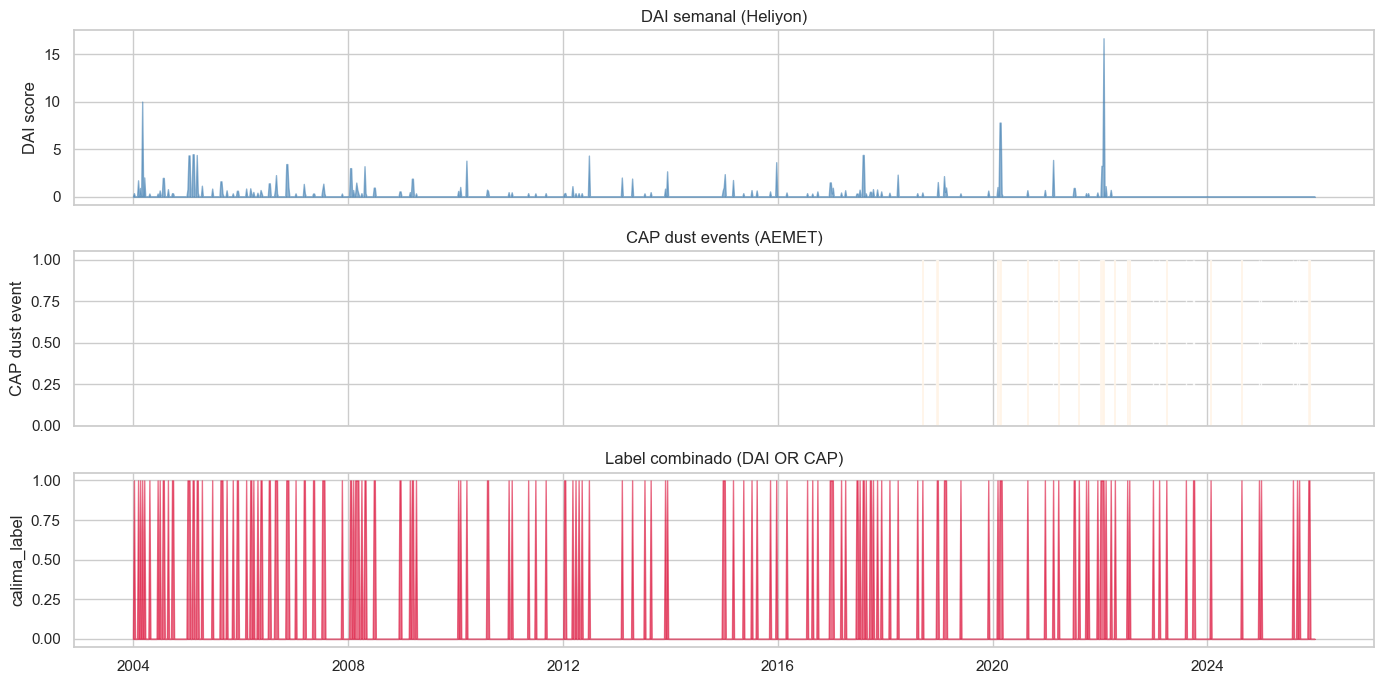

In [8]:
# Timeline de eventos calima
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(df['week_start'], df['calima_canarias_dai_week'].fillna(0),
                     alpha=0.6, color='steelblue')
axes[0].set_ylabel('DAI score')
axes[0].set_title('DAI semanal (Heliyon)')

axes[1].bar(cap_available['week_start'], cap_available['cap_dust_event'],
            width=5, color='darkorange', alpha=0.8)
axes[1].set_ylabel('CAP dust event')
axes[1].set_title('CAP dust events (AEMET)')

axes[2].fill_between(df['week_start'], df['calima_label'].fillna(0),
                     alpha=0.6, color='crimson')
axes[2].set_ylabel('calima_label')
axes[2].set_title('Label combinado (DAI OR CAP)')

plt.tight_layout()
plt.savefig('../reports/ccaa/figures/calibration_label_timeline.png', dpi=150)
plt.show()

## 3. EDA de calibración — distribuciones por label

Para cada variable física: ¿cómo se distribuye en semanas calima (label=1) vs no calima (label=0)?  
Esto nos muestra qué variables discriminan mejor.

In [10]:
# Usamos la ventana 2009–2022: DAI fiable + CAP disponible desde 2018
calib = df[
    (df['week_start'] >= '2009-01-01') &
    (df['week_start'] <= '2022-12-31') &
    (df['calima_label'].notna())
].copy()
calib['calima_label'] = calib['calima_label'].astype(int)

print(f"Ventana calibración 2009–2022: {len(calib)} semanas")
print(f"  calima=1: {calib['calima_label'].sum()} | calima=0: {(calib['calima_label']==0).sum()}")

Ventana calibración 2009–2022: 730 semanas
  calima=1: 92 | calima=0: 638


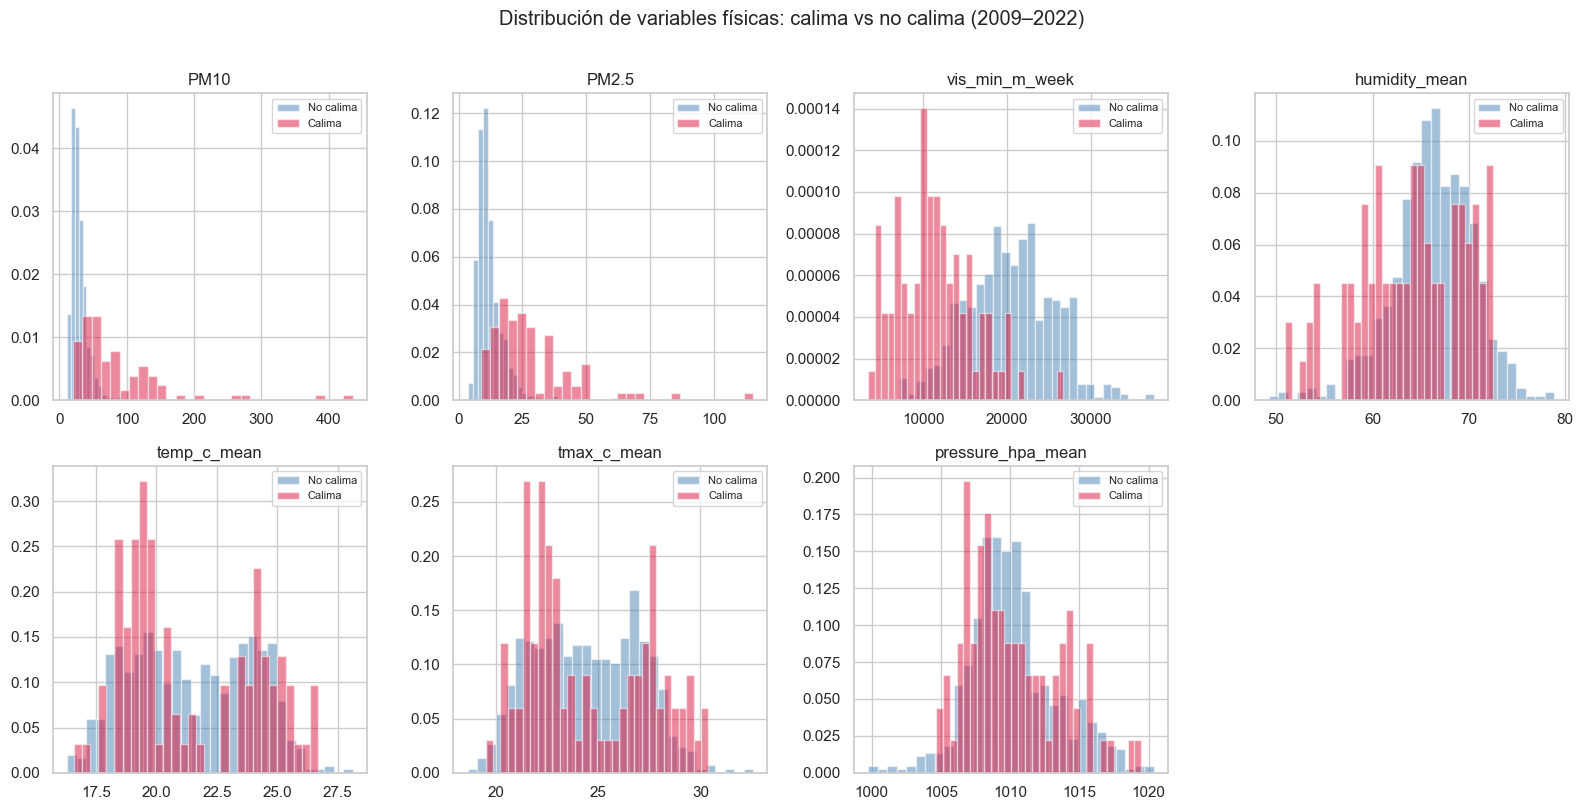

In [12]:
FEATURES = ['PM10', 'PM2.5', 'vis_min_m_week', 'humidity_mean',
            'temp_c_mean', 'tmax_c_mean', 'pressure_hpa_mean']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(FEATURES):
    ax = axes[i]
    for label, color, name in [(0, 'steelblue', 'No calima'), (1, 'crimson', 'Calima')]:
        data = calib[calib['calima_label'] == label][var].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de variables físicas: calima vs no calima (2009–2022)', y=1.01)
plt.tight_layout()
plt.savefig('../reports/CCAA/figures/calibration_distributions.png', dpi=150)
plt.show()

In [13]:
# Percentiles por grupo
print("Percentiles p25 / p50 / p75 / p90 por variable y label:\n")
for var in FEATURES:
    print(f"--- {var} ---")
    for label, name in [(0, 'No calima'), (1, 'Calima')]:
        g = calib[calib['calima_label'] == label][var].dropna()
        print(f"  {name}: p25={g.quantile(0.25):.2f}  p50={g.quantile(0.50):.2f}  "
              f"p75={g.quantile(0.75):.2f}  p90={g.quantile(0.90):.2f}")
    print()

Percentiles p25 / p50 / p75 / p90 por variable y label:

--- PM10 ---
  No calima: p25=21.63  p50=26.99  p75=34.30  p90=45.10
  Calima: p25=45.90  p50=63.62  p75=114.12  p90=143.92

--- PM2.5 ---
  No calima: p25=8.66  p50=10.68  p75=13.64  p90=18.52
  Calima: p25=17.52  p50=23.26  p75=36.05  p90=48.98

--- vis_min_m_week ---
  No calima: p25=16841.67  p50=20333.33  p75=24000.00  p90=26716.67
  Calima: p25=8054.17  p50=11083.33  p75=14050.00  p90=17483.33

--- humidity_mean ---
  No calima: p25=63.94  p50=66.38  p75=69.12  p90=71.21
  Calima: p25=60.00  p50=64.30  p75=68.89  p90=71.02

--- temp_c_mean ---
  No calima: p25=19.40  p50=21.33  p75=23.65  p90=24.70
  Calima: p25=19.13  p50=20.39  p75=24.11  p90=25.19

--- tmax_c_mean ---
  No calima: p25=22.35  p50=24.32  p75=26.68  p90=27.75
  Calima: p25=22.09  p50=23.48  p75=27.39  p90=28.59

--- pressure_hpa_mean ---
  No calima: p25=1008.20  p50=1009.85  p75=1011.76  p90=1015.04
  Calima: p25=1007.62  p50=1009.48  p75=1012.59  p90=1014

**Conclusión antes de la regresión:** el proxy v4 debería usar solo 3 variables: PM10 + PM2.5 + vis_min_m_week. Las otras 4 añaden ruido sin señal.
Esto tiene sentido físicamente — la calima es un fenómeno de polvo en suspensión. PM10 y PM2.5 lo capturan directamente; la visibilidad lo confirma. La temperatura no discrimina a escala regional semanal porque la nube de polvo puede llegar con o sin calor extremo dependiendo de la trayectoria.

## 4. Regresión logística — calibración del proxy

El modelo aprende qué combinación de variables físicas mejor predice `calima_label=1`.  
Los coeficientes resultantes son los pesos del proxy v4.

In [14]:
# Preparar datos — imputar 19 nulls de visibilidad con mediana
FEATURES = ['PM10', 'PM2.5', 'vis_min_m_week'] #Actualizado segun las variables que mejor miden la calima.
calib_model = calib[FEATURES + ['calima_label']].copy()
for col in FEATURES:
    calib_model[col] = calib_model[col].fillna(calib_model[col].median())

X = calib_model[FEATURES].values
y = calib_model['calima_label'].values

# Pipeline: estandarizar + logística
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipe.fit(X, y)

# Coeficientes (en escala estandarizada — muestran importancia relativa)
coefs = pd.Series(pipe.named_steps['logit'].coef_[0], index=FEATURES)
print("Coeficientes logística (estandarizados):")
print(coefs.sort_values(ascending=False))

Coeficientes logística (estandarizados):
PM10              0.799
PM2.5             0.682
vis_min_m_week   -1.376
dtype: float64


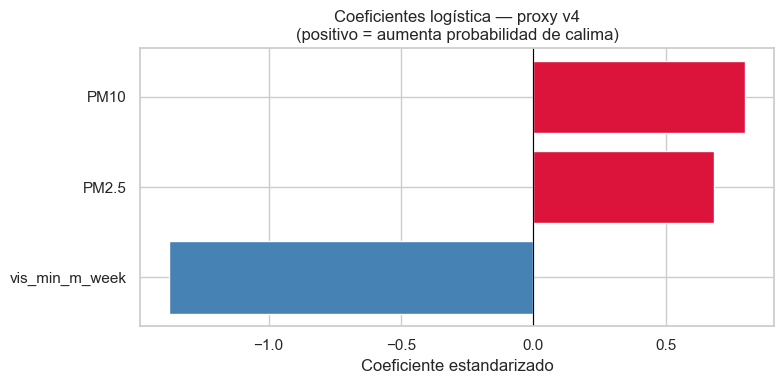

In [17]:
# Visualizar coeficientes
fig, ax = plt.subplots(figsize=(8, 4))
coefs_sorted = coefs.sort_values()
colors = ['crimson' if c > 0 else 'steelblue' for c in coefs_sorted]
ax.barh(coefs_sorted.index, coefs_sorted.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes logística — proxy v4\n(positivo = aumenta probabilidad de calima)')
ax.set_xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.savefig('../reports/CCAA/figures/calibration_coefficients.png', dpi=150)
plt.show()

## 5. Evaluación — AUC y curva ROC

AUC (ventana calibración 2009–2022): 0.9319


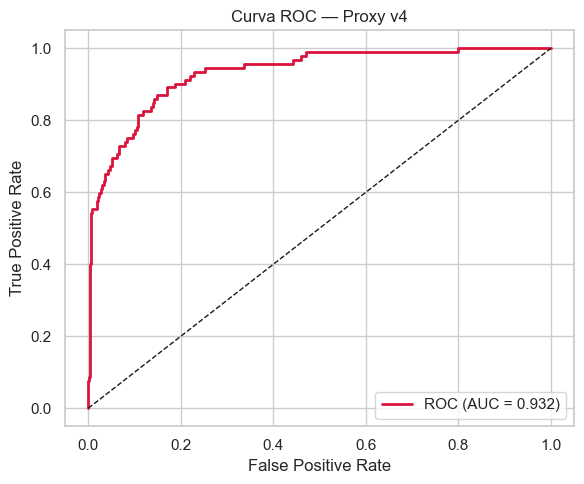


              precision    recall  f1-score   support

   no_calima       0.94      0.99      0.96       638
      calima       0.91      0.55      0.69        92

    accuracy                           0.94       730
   macro avg       0.92      0.77      0.83       730
weighted avg       0.94      0.94      0.93       730



In [19]:
y_prob = pipe.predict_proba(X)[:, 1]
auc = roc_auc_score(y, y_prob)
print(f"AUC (ventana calibración 2009–2022): {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Proxy v4')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/CCAA/figures/calibration_roc.png', dpi=150)
plt.show()

print()
print(classification_report(y, pipe.predict(X), target_names=['no_calima', 'calima']))

## 6. Umbrales ordinales

Dividimos la probabilidad predicha [0–1] en 4 niveles usando percentiles del score en la ventana de calibración.  
Equivalente a los niveles del proxy v2: `no_calima / possible / probable / intense`

Umbrales candidatos:
  no_calima  → score < 0.0474  (60% de semanas)
  possible   → 0.0474 ≤ score < 0.1546  (20%)
  probable   → 0.1546 ≤ score < 0.5760  (13%)
  intense    → score ≥ 0.5760  (7%)


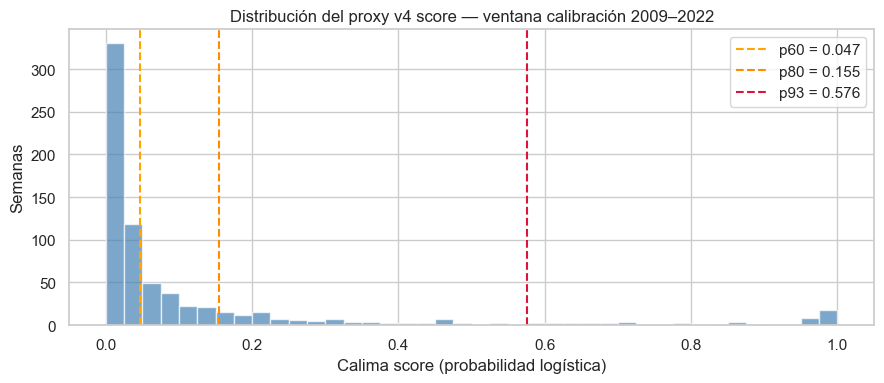

In [22]:
# Score en toda la ventana calibración
scores_calib = pd.Series(y_prob)

# Percentiles para definir los 4 niveles
# p60 = no_calima|possible  |  p80 = possible|probable  |  p93 = probable|intense
# Ajusta estos valores tras ver la distribución
p60 = float(np.percentile(scores_calib, 60))
p80 = float(np.percentile(scores_calib, 80))
p93 = float(np.percentile(scores_calib, 93))

print(f"Umbrales candidatos:")
print(f"  no_calima  → score < {p60:.4f}  ({60}% de semanas)")
print(f"  possible   → {p60:.4f} ≤ score < {p80:.4f}  (20%)")
print(f"  probable   → {p80:.4f} ≤ score < {p93:.4f}  (13%)")
print(f"  intense    → score ≥ {p93:.4f}  (7%)")

# Distribución del score
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_calib, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
for t, label, color in [(p60, 'p60', 'orange'), (p80, 'p80', 'darkorange'), (p93, 'p93', 'crimson')]:
    ax.axvline(t, color=color, linestyle='--', lw=1.5, label=f'{label} = {t:.3f}')
ax.set_xlabel('Calima score (probabilidad logística)')
ax.set_ylabel('Semanas')
ax.set_title('Distribución del proxy v4 score — ventana calibración 2009–2022')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/CCAA/figures/calibration_score_distribution.png', dpi=150)
plt.show()

In [23]:
# Verificar que los umbrales capturan bien los eventos conocidos
calib_scored = calib_model.copy()
calib_scored['calima_score'] = y_prob
calib_scored['calima_level'] = pd.cut(
    calib_scored['calima_score'],
    bins=[-np.inf, p60, p80, p93, np.inf],
    labels=['no_calima', 'possible', 'probable', 'intense']
)

print("Distribución de niveles:")
print(calib_scored['calima_level'].value_counts().sort_index())
print()
print("Tasa de calima_label=1 por nivel (debería subir de no_calima a intense):")
print(calib_scored.groupby('calima_level')['calima_label'].mean().round(3))

Distribución de niveles:
calima_level
no_calima    438
possible     146
probable      94
intense       52
Name: count, dtype: int64

Tasa de calima_label=1 por nivel (debería subir de no_calima a intense):
calima_level
no_calima   0.011
possible    0.082
probable    0.287
intense     0.923
Name: calima_label, dtype: float64


C:\Users\fdora\AppData\Local\Temp\ipykernel_30020\323603426.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(calib_scored.groupby('calima_level')['calima_label'].mean().round(3))


## 7. Exportar coeficientes y umbrales

In [24]:
# Guardar como JSON para usar en build_master_regional.py
scaler = pipe.named_steps['scaler']
logit  = pipe.named_steps['logit']

proxy_config = {
    'features': FEATURES,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_std': scaler.scale_.tolist(),
    'logit_coef': logit.coef_[0].tolist(),
    'logit_intercept': float(logit.intercept_[0]),
    'thresholds': {
        'no_calima_max': round(p60, 6),
        'possible_max':  round(p80, 6),
        'probable_max':  round(p93, 6),
    },
    'auc_calibration': round(auc, 4),
    'calibration_window': '2009-2022',
    'label_source': 'DAI (Heliyon) OR CAP dust >= amarillo (AEMET)'
}

config_path = OUT_DIR / 'proxy_v4_config.json'
with open(config_path, 'w') as f:
    json.dump(proxy_config, f, indent=2)

print(f"Configuración guardada: {config_path}")
print()
print(json.dumps(proxy_config, indent=2))

Configuración guardada: ..\data\processed\regional\proxy_v4_config.json

{
  "features": [
    "PM10",
    "PM2.5",
    "vis_min_m_week"
  ],
  "scaler_mean": [
    37.03162617364118,
    14.037956741414723,
    19216.99502283105
  ],
  "scaler_std": [
    33.40527836540273,
    9.56914892664872,
    5889.9004842769655
  ],
  "logit_coef": [
    0.7994663174667599,
    0.6818721406579112,
    -1.3758767897330197
  ],
  "logit_intercept": -3.055770775184978,
  "thresholds": {
    "no_calima_max": 0.047442,
    "possible_max": 0.154648,
    "probable_max": 0.575951
  },
  "auc_calibration": 0.9319,
  "calibration_window": "2009-2022",
  "label_source": "DAI (Heliyon) OR CAP dust >= amarillo (AEMET)"
}
